In [1]:
%cd ..

/common/wut4/workspace/OCT


In [2]:
import os

import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
from collections import Counter

from tensorboard.backend.event_processing import event_accumulator
from matplotlib import pyplot as plt
from sklearn.metrics import f1_score

In [3]:
result_dir = 'results/20250122-153547'

In [4]:
train_df = pd.read_csv(os.path.join(result_dir, 'train_df.csv'))
valid_df = pd.read_csv(os.path.join(result_dir, 'valid_df.csv'))
test_df = pd.read_csv(os.path.join(result_dir, 'test_df.csv'))

In [5]:
print(f"total image: {len(train_df)}")
print(f"total ID: {len(set(train_df['ID']))}")
print(f"total case: {len(set(train_df['case']))}")
Counter(train_df['date'])

total image: 22800
total ID: 15
total case: 76


Counter({'P40': 8400, 'P60': 7200, 'P90': 5400, 'P120': 1500, 'P150': 300})

In [6]:
print(f"total image: {len(valid_df)}")
print(f"total ID: {len(set(valid_df['ID']))}")
print(f"total case: {len(set(valid_df['case']))}")
Counter(valid_df['date'])

total image: 5700
total ID: 5
total case: 19


Counter({'P40': 2700, 'P60': 2400, 'P90': 600})

In [7]:
print(f"total image: {len(test_df)}")
print(f"total ID: {len(set(test_df['ID']))}")
print(f"total case: {len(set(test_df['case']))}")
Counter(test_df['date'])

total image: 9000
total ID: 6
total case: 30


Counter({'P40': 3300, 'P60': 2400, 'P90': 2100, 'P120': 900, 'P150': 300})

In [8]:
# Load tf files
tb_file = [item for item in os.listdir(os.path.join(result_dir, 'lightning_logs', 'version_0')) if item.startswith('events')]
assert len(tb_file) == 1
tb_path = os.path.join(result_dir, 'lightning_logs', 'version_0', tb_file[0])
assert os.path.isfile(tb_path)

In [9]:
ea = event_accumulator.EventAccumulator(tb_path,
            size_guidance={ # see below regarding this argument
            event_accumulator.COMPRESSED_HISTOGRAMS: 500,
            event_accumulator.IMAGES: 4,
            event_accumulator.AUDIO: 4,
            event_accumulator.SCALARS: 0,
            event_accumulator.HISTOGRAMS: 1,
        })

ea.Reload() # loads events from file

In [10]:
val_loss = [item.value for item in ea.Scalars('val_loss')]
print(f"val loss length: {len(val_loss)}")
train_loss = [item.value for item in ea.Scalars('train_loss_step')]
print(f"train loss length: {len(train_loss)}")

# moving average on train loss
train_loss = np.array(train_loss)
final_size = len(val_loss)
step = len(train_loss) // final_size
moving_averages = [np.mean(train_loss[i:i+step]) for i in range(0, len(train_loss), step)]


val loss length: 43
train loss length: 3065


In [11]:
data = {
    'trained_step': [i * 50 for i in range(len(moving_averages))],
    'training_loss': moving_averages,
    'validation_loss': val_loss
}

df = pd.DataFrame.from_dict(data, orient='index').transpose()
df.to_csv(os.path.join(result_dir, 'loss_data.csv'), index=False) 

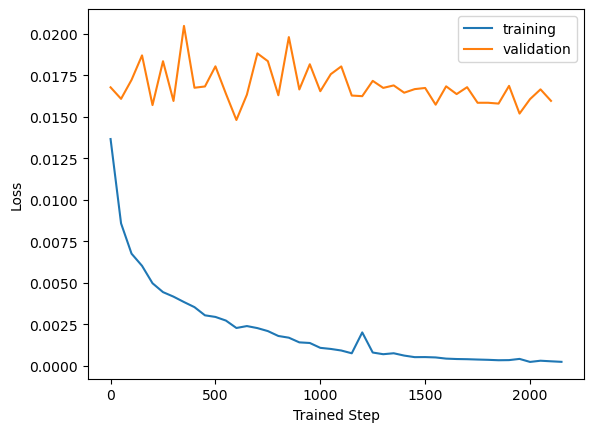

In [12]:
# Plot train/valid loss
plt.plot([item*50 for item in range(len(moving_averages))], moving_averages, label='training')
plt.plot([item*50 for item in range(len(val_loss))], val_loss, label='validation')
plt.xlabel('Trained Step')
plt.ylabel('Loss')
plt.legend()
plt.savefig(os.path.join(result_dir, 'loss_plot.png'))

output_path = os.path.join(result_dir, 'loss_plot.tiff')
plt.savefig(output_path, format='tiff', dpi=300, bbox_inches='tight', pil_kwargs={"rgb_mode": "RGB"})

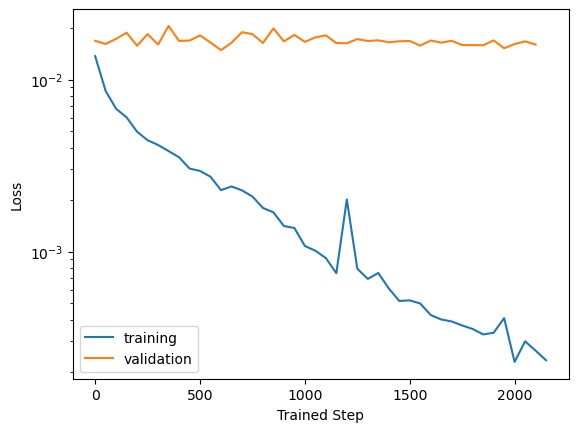

In [13]:
# Plot train/valid loss with log scale
plt.plot([item*50 for item in range(len(moving_averages))], moving_averages, label='training')
plt.plot([item*50 for item in range(len(val_loss))], val_loss, label='validation')
plt.xlabel('Trained Step')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.savefig(os.path.join(result_dir, 'loss_plot_log.png'))

output_path = os.path.join(result_dir, 'loss_plot_log.tiff')
plt.savefig(output_path, format='tiff', dpi=300, bbox_inches='tight', pil_kwargs={"rgb_mode": "RGB"})

In [14]:
gt = np.load(os.path.join(result_dir, 'gt.npy'))
pred = np.load(os.path.join(result_dir, 'pred.npy'))

In [15]:
df = pd.read_csv(os.path.join(result_dir, "test_df.csv"))
df['value2'] = gt
df['pred'] = pred

In [16]:
df.to_csv(os.path.join(result_dir, 'test_df_all.csv'), index=False)

In [21]:
mse_loss = np.mean((df['value'] - df['pred']) ** 2)
mae_loss = np.mean(np.abs(df['value'] - df['pred']))
corr = df[['value', 'pred']].corr(method='spearman').iloc[0]['pred']
print(f'Total: MSE {mse_loss:.3f}, MAE {mae_loss:.3f}| Spearman corr: {corr:.3f}')

total_date = ['P40', 'P60', 'P90', 'P120', 'P150']
for date in total_date:
    sub_df = df[df['date'] == date]

    mse_loss = np.mean((sub_df['value'] - sub_df['pred']) ** 2)
    mae_loss = np.mean(np.abs(sub_df['value'] - sub_df['pred']))

    unique_case = sub_df.drop_duplicates(subset=['date', 'ID', 'side'])
    unique_ID = sub_df.drop_duplicates(subset=['date', 'ID'])
    corr = sub_df[['value', 'pred']].corr(method='spearman').iloc[0]['pred']

    print(f'{date}: {len(unique_ID)} IDs {len(unique_case)} cases {len(sub_df)} images | MSE {mse_loss:.3f}, MAE {mae_loss:.3f}| Spearman corr: {corr:.3f}')

    if date == 'P40':
        sub_df = sub_df[sub_df['value'] > 0.3]
        mse_loss = np.mean((sub_df['value'] - sub_df['pred']) ** 2)
        mae_loss = np.mean(np.abs(sub_df['value'] - sub_df['pred']))
    
        unique_case = sub_df.drop_duplicates(subset=['date', 'ID', 'side'])
        unique_ID = sub_df.drop_duplicates(subset=['date', 'ID'])
        corr = sub_df[['value', 'pred']].corr(method='spearman').iloc[0]['pred']
    
        print(f'P40 (remove <0.3): {len(unique_ID)} IDs {len(unique_case)} cases {len(sub_df)} images | MSE {mse_loss:.3f}, MAE {mae_loss:.3f}| Spearman corr: {corr:.3f}')

Total: MSE 0.011, MAE 0.069| Spearman corr: 0.787
P40: 6 IDs 11 cases 3300 images | MSE 0.024, MAE 0.108| Spearman corr: -0.074
P40 (remove <0.3): 6 IDs 9 cases 2700 images | MSE 0.005, MAE 0.060| Spearman corr: 0.157
P60: 4 IDs 8 cases 2400 images | MSE 0.003, MAE 0.040| Spearman corr: 0.122
P90: 4 IDs 7 cases 2100 images | MSE 0.004, MAE 0.060| Spearman corr: 0.235
P120: 2 IDs 3 cases 900 images | MSE 0.002, MAE 0.039| Spearman corr: -0.143
P150: 1 IDs 1 cases 300 images | MSE 0.001, MAE 0.021| Spearman corr: nan


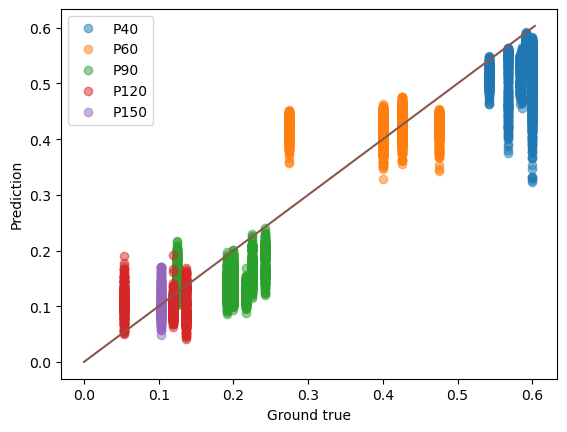

In [18]:
total_date = ['P40', 'P60', 'P90', 'P120', 'P150']
for idx, date in enumerate(total_date):
    sub_df = df[df['date'] == date]

    if date == 'P40':
        sub_df = sub_df[sub_df['value'] > 0.3]
    plt.plot(sub_df['value'], sub_df['pred'], 'o', label=date, alpha=0.5)
plt.plot([0, df['pred'].max()], [0, df['pred'].max()])
plt.xlabel('Ground true')
plt.ylabel('Prediction')
plt.legend()

Text(0.5, 1.0, 'P40')

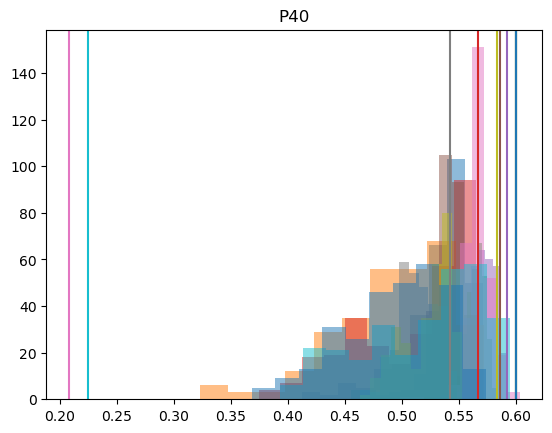

In [19]:
date = 'P40'
sub_df = df[df['date'] == date]
unique_case = sub_df.drop_duplicates(subset=['date', 'ID', 'side'])
for i in range(len(unique_case)):
    curr_id = unique_case.iloc[i]['ID']
    curr_side = unique_case.iloc[i]['side']
    tmp_df = sub_df[(sub_df['ID'] == curr_id) & (sub_df['side'] == curr_side)]
    plt.axvline(x=unique_case.iloc[i]['value'], color=f'C{i}')
    plt.hist(tmp_df['pred'], alpha=0.5, label=f'{curr_id}_{curr_side}')
# plt.legend()
plt.title(f'{date}')

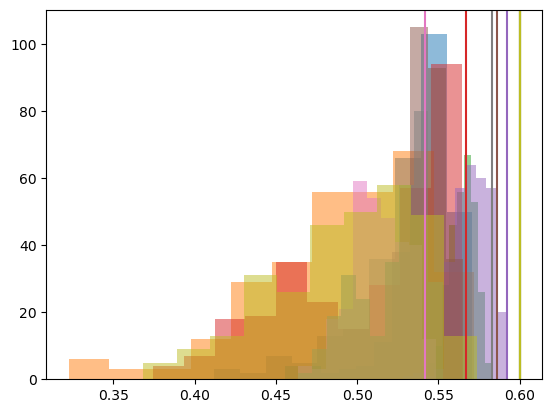

In [20]:
date = 'P40'
sub_df = df[df['date'] == date]
sub_df = sub_df[sub_df['value'] > 0.3]
unique_case = sub_df.drop_duplicates(subset=['date', 'ID', 'side'])
for i in range(len(unique_case)):
    curr_id = unique_case.iloc[i]['ID']
    curr_side = unique_case.iloc[i]['side']
    tmp_df = sub_df[(sub_df['ID'] == curr_id) & (sub_df['side'] == curr_side)]
    plt.axvline(x=unique_case.iloc[i]['value'], color=f'C{i}')
    plt.hist(tmp_df['pred'], alpha=0.5, label=f'{curr_id}_{curr_side}')
# plt.legend()

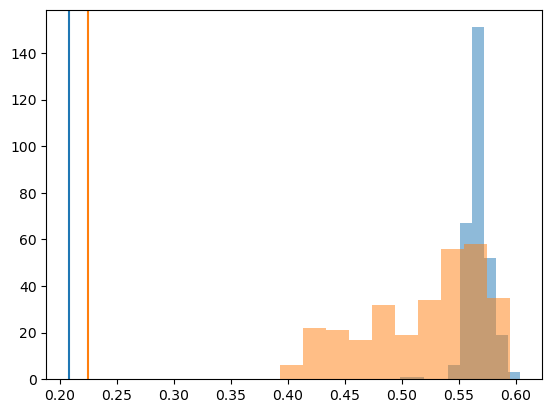

In [21]:
date = 'P40'
sub_df = df[df['date'] == date]
sub_df = sub_df[sub_df['value'] < 0.3]
unique_case = sub_df.drop_duplicates(subset=['date', 'ID', 'side'])
for i in range(len(unique_case)):
    curr_id = unique_case.iloc[i]['ID']
    curr_side = unique_case.iloc[i]['side']
    tmp_df = sub_df[(sub_df['ID'] == curr_id) & (sub_df['side'] == curr_side)]
    plt.axvline(x=unique_case.iloc[i]['value'], color=f'C{i}')
    plt.hist(tmp_df['pred'], alpha=0.5, label=f'{curr_id}_{curr_side}')
# plt.legend()

Text(0.5, 1.0, 'P60')

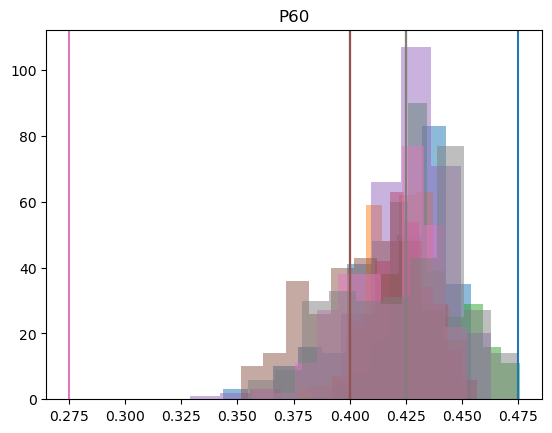

In [22]:
date = 'P60'
sub_df = df[df['date'] == date]
unique_case = sub_df.drop_duplicates(subset=['date', 'ID', 'side'])
for i in range(len(unique_case)):
    curr_id = unique_case.iloc[i]['ID']
    curr_side = unique_case.iloc[i]['side']
    tmp_df = sub_df[(sub_df['ID'] == curr_id) & (sub_df['side'] == curr_side)]
    plt.axvline(x=unique_case.iloc[i]['value'], color=f'C{i}')
    plt.hist(tmp_df['pred'], alpha=0.5, label=f'{curr_id}_{curr_side}')
# plt.legend()
plt.title(f'{date}')

Text(0.5, 1.0, 'P90')

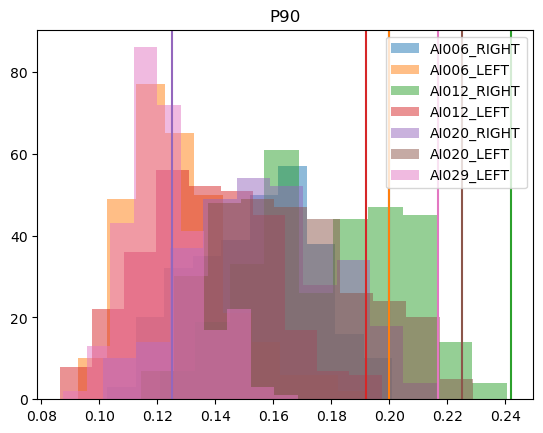

In [23]:
date = 'P90'
sub_df = df[df['date'] == date]
unique_case = sub_df.drop_duplicates(subset=['date', 'ID', 'side'])
for i in range(len(unique_case)):
    curr_id = unique_case.iloc[i]['ID']
    curr_side = unique_case.iloc[i]['side']
    tmp_df = sub_df[(sub_df['ID'] == curr_id) & (sub_df['side'] == curr_side)]
    plt.axvline(x=unique_case.iloc[i]['value'], color=f'C{i}')
    plt.hist(tmp_df['pred'], alpha=0.5, label=f'{curr_id}_{curr_side}')
plt.legend()
plt.title(f'{date}')

Text(0.5, 1.0, 'P120')

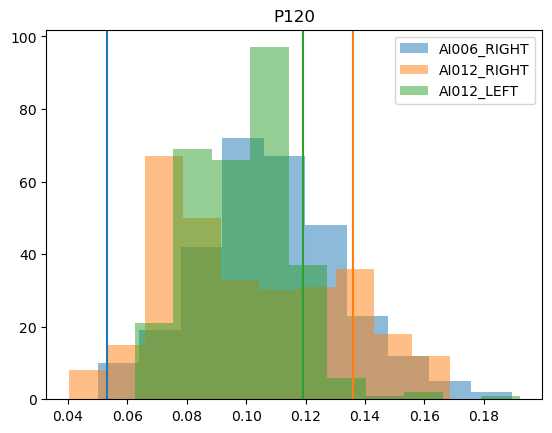

In [24]:
date = 'P120'
sub_df = df[df['date'] == date]
unique_case = sub_df.drop_duplicates(subset=['date', 'ID', 'side'])
for i in range(len(unique_case)):
    curr_id = unique_case.iloc[i]['ID']
    curr_side = unique_case.iloc[i]['side']
    tmp_df = sub_df[(sub_df['ID'] == curr_id) & (sub_df['side'] == curr_side)]
    plt.axvline(x=unique_case.iloc[i]['value'], color=f'C{i}')
    plt.hist(tmp_df['pred'], alpha=0.5, label=f'{curr_id}_{curr_side}')
plt.legend()
plt.title(f'{date}')

Text(0.5, 1.0, 'P150')

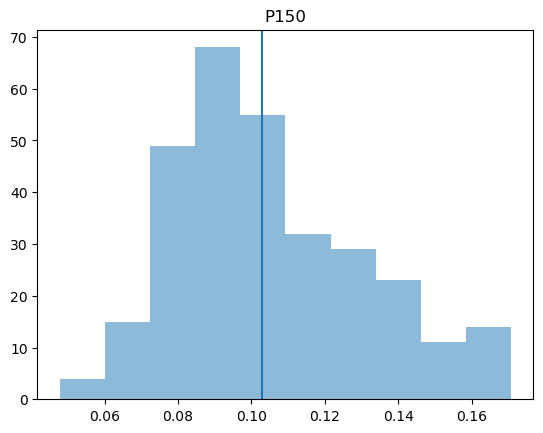

In [25]:
date = 'P150'
sub_df = df[df['date'] == date]
unique_case = sub_df.drop_duplicates(subset=['date', 'ID', 'side'])
for i in range(len(unique_case)):
    curr_id = unique_case.iloc[i]['ID']
    curr_side = unique_case.iloc[i]['side']
    tmp_df = sub_df[(sub_df['ID'] == curr_id) & (sub_df['side'] == curr_side)]
    plt.axvline(x=unique_case.iloc[i]['value'], color=f'C{i}')
    plt.hist(tmp_df['pred'], alpha=0.5, label=f'{curr_id}_{curr_side}')
# plt.legend()
plt.title(f'{date}')